In [4]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sns.set_theme(style='darkgrid')

# load price history
data_folder = '../data/'
for file in os.listdir(data_folder):
    if 'price_history_full' in file:
        df = pd.read_csv(data_folder + file)

launch_ref = pd.read_csv('../data/official_launch_prices.csv')
df = df.merge(launch_ref, on='submodel_name')
df['official_premiere_date'] = pd.to_datetime(df['official_premiere_date'])
df['datetime'] = pd.to_datetime(df['datetime'])
df['days_since_launch'] = (df['datetime'] - df['official_premiere_date']).dt.days
df = df[df['days_since_launch'] > 0]
df['NEW'] = df['new_price'] * 100
df = df.drop('new_price', axis=1)
df['price_pct_of_launch'] = round(df['NEW'] / df['official_launch_price'] * 100, 1)
df['days_rounded'] = (df['days_since_launch'] / 7).round() * 7
df['tier'] = df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
df['tier'] = df['tier'].replace('', 'Base')

# load monthly sold
ms_df = pd.read_csv('../data/monthly_sold_full.csv')
ms_df = ms_df.merge(launch_ref, on='submodel_name', how='left')
ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])
del ms_df['premiere_date']
ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]
ms_df['tier'] = ms_df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')

# price decay dataframes
base_apple_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple') & (df['generation_name'] != 'iPhone 17')]
base_apple_decay_df = base_apple_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_samsung_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Samsung')]
base_samsung_decay_df = base_samsung_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_google_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Google')]
base_google_decay_df = base_google_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_combined_df = df[df['tier'] == 'Base']
all_brands_decay_df = base_combined_df.groupby(['brand', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

grouped_generation_decay_df = df.groupby(['submodel_name', 'generation_name', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()
iphone13_decay_df = grouped_generation_decay_df[grouped_generation_decay_df['generation_name'] == 'iPhone 13']

# 1-year retention
yearly_change_df = df[(df['days_rounded'] > 330) & (df['days_rounded'] < 380)]
retention_1yr_df = yearly_change_df.groupby('generation_name').agg(
    price_retention=('price_pct_of_launch', 'mean'),
    brand=('brand', 'first')
).reset_index().sort_values('price_retention', ascending=False)

brand_retention = retention_1yr_df.groupby('brand')['price_retention'].mean()
apple_retention = brand_retention['Apple']
samsung_retention = brand_retention['Samsung']
google_retention = brand_retention['Google']

grade_means = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple')].groupby('product_grade')['price_pct_of_launch'].mean()
renewed_premium_premium = grade_means['Renewed Premium'] - grade_means['Renewed']

# sales rank dataframes
apple_base_rank_df = ms_df[(ms_df['tier'] == 'Base') & (ms_df['brand'] == 'Apple') & (ms_df['monthly_sold'] >= 0)]
apple_base_rank_df = apple_base_rank_df.groupby(['generation_name', 'days_rounded'])['monthly_sold'].mean().reset_index()

iphone13_rank_df = ms_df[ms_df['generation_name'] == 'iPhone 13']
iphone13_rank_df = iphone13_rank_df.groupby(['submodel_name', 'days_rounded'])['monthly_sold'].mean().reset_index()

iphone15_rank_df = ms_df[ms_df['generation_name'] == 'iPhone 15']
iphone15_rank_df = iphone15_rank_df.groupby(['submodel_name', 'days_rounded'])['monthly_sold'].mean().reset_index()


rank_dates_gen_df = (ms_df.set_index('datetime')
    .groupby(['generation_name', 'brand', 'tier'])
    .resample('W')['monthly_sold'].mean().reset_index())
rank_dates_gen_df['monthly_sold'] = rank_dates_gen_df.groupby('generation_name')['monthly_sold'].ffill()
apple_base_rank_dates_df = rank_dates_gen_df[
    (rank_dates_gen_df['tier'] == 'Base') &
    (rank_dates_gen_df['brand'] == 'Apple') &
    (rank_dates_gen_df['monthly_sold'] >= 0)
]

rank_dates_sub_df = (ms_df.set_index('datetime')
    .groupby(['submodel_name', 'brand', 'generation_name'])
    .resample('W')['monthly_sold'].mean().reset_index())
rank_dates_sub_df['monthly_sold'] = rank_dates_sub_df.groupby('generation_name')['monthly_sold'].ffill()
iphone13_rank_dates_df = rank_dates_sub_df[rank_dates_sub_df['generation_name'] == 'iPhone 13']
iphone15_rank_dates_df = rank_dates_sub_df[rank_dates_sub_df['generation_name'] == 'iPhone 15']


# Analiza cen smartfonów na Amazon

#Metodologia i dane
Do analizy pobrałem rzeczywiste dane cenowe pozyskane przez płatne API Keepa z rynku wtórnego Amazon US.
Skupiłem się na trzech markach (Apple, Google, Samsung) i łącznie na 63 submodelach.
Do analizy cenowej wykorzystałem 878 000 tygodniowych rekordów cenowych z lat 2019-2026.
Badałem też wielkość sprzedaży na podstawie ponad 18000+ miesięcznych odczytów rankingów sprzedażowych.

Analiza zaczyna się od porównania na poziomie marek, a następnie bardziej szczegółowo przyjrzałem się iPhone'om.

Pytanie jest proste: jak szybko telefon traci wartość po trafieniu na rynek wtórny i czy zależy to od marki, wariantu modelu albo miesiąca? Czy istnieją jakieś wzorce i zależności między markami i submodelami?

**Kilka słów o projekcie**

Dane zostały pobrane z Keepa API mniej więcej w lutym 2026. Zapisałem je w lokalnej bazie PostgreSQL, agregowałem i badałem przy użyciu SQLa oraz wizualizacji w Power BI.

Potem projekt odłożyłem na bok m.in dlatego, że dane sprawiły mi sporo problemów i skupiłem się chwilowo na innych tematach, ale na początku maja postanowiłem, że zacznę od nowa i zrobię jednak projekt w Pythonie, zarówno jako pozycję do portfolio, jak i projekt zaliczeniowy na kurs Crappy Data.

Jakieś 70-80% czasu pochłonęło iteracyjne EDA, testowanie różnych poziomów agregacji, obsługa edge case'ów, korekty podejścia i walka z różnymi problemami. Miałem kilka większych cofek, gdy np. okazywało się, że brakuje mi znacznej ilości danych albo podjąłem jakąś złą decyzję wcześniej.

Ostatecznie zdecydowałem się na wartości relatywne (% ceny z dnia premiery zamiast dolarów), choć rozważam dodanie ich zanim wrzucę projekt do portfolio.

Poniżej przykłady wyzwań, na które natrafiłem:

- Każdy wariant produktu (np. iPhone 14 128GB Red Renewed Premium) miał własny kod ASIN i dane śledzone tylko dla tej konkretnej konfiguracji (kolor, wielkość pamięci, klasa produktu). Trzeba było to zidentyfikować i przemyśleć, jak sensownie agregować dane
- Daty w API były podawane w nietypowy sposób: liczba minut od 2011-01-01 (tzw. KeepaTime)
- Historia śledzenia cen miała luki między datą premiery a początkiem śledzenia, prawdopodobnie dlatego, że śledzimy rynek wtórny, a nie sprzedaż bezpośrednią
- Ceny były podzielone przez 100
- Pole monthly_sold reprezentuje ranking sprzedaży, a nie liczbę sprzedanych sztuk
- Dane o wolumenie sprzedaży ostatecznie musiałem pominąć, mimo tego, że biorąc się za projekt liczyłem na to, że będą stanowiły trzon analizy. Dostępne dane pobrane z API okazały się jednak ograniczone, niedokładne i podawały jedynie orientacyjny zakres zamiast konkretnych liczb. Była to trudna decyzja, ale jedyna logiczna, żeby nie zaśmiecać wniosków

Analiza dotyczy praktycznie wyłącznie telefonów z kategorii Renewed a w przypadku Apple mamy klasy Renewed i Renewed Premium.

Ceny początkowe (official_launch_price) najpierw agregowałem ręcznie na podstawie danych z API Keepy, ale ostatecznie zebrałem je ręcznie z oficjalnych danych jako średnią cenę dla wszystkich wariantów pamięci dla danego submodelu (czyli np. w przypadku iPhone'a 16 Pro, ceną official_launch_price będzie średnia z wszystkich wariantów pamięciowych).

Najnowsze smartfony (np. iPhone 17) zostały pominięte ze względu na zbyt krótką historię cenową.

---
## Przegląd projektu

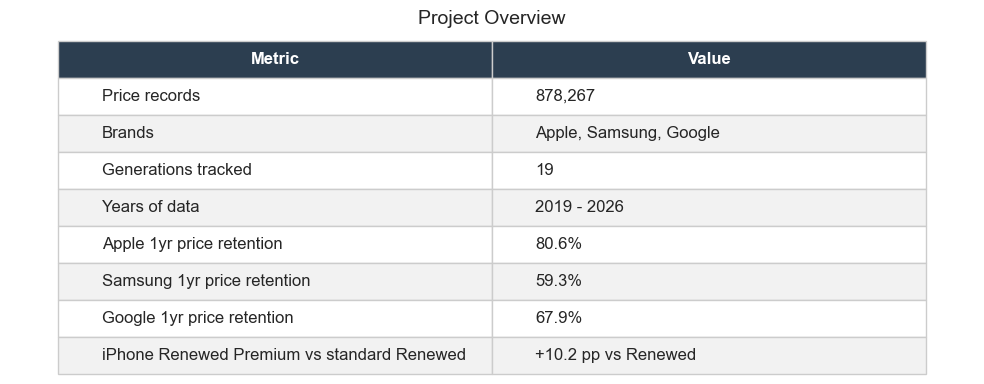

In [20]:
kpi_data = [
    ['Price records', '878,267'],
    ['Brands', 'Apple, Samsung, Google'],
    ['Generations tracked', str(df['generation_name'].nunique())],
    ['Years of data', '2019 - 2026'],
    ['Apple 1yr price retention', f'{round(apple_retention, 1)}%'],
    ['Samsung 1yr price retention', f'{round(samsung_retention, 1)}%'],
    ['Google 1yr price retention', f'{round(google_retention, 1)}%'],
    ['iPhone Renewed Premium vs standard Renewed', f'+{round(renewed_premium_premium, 1)} pp vs Renewed'],
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=kpi_data,
    colLabels=['Metric', 'Value'],
    cellLoc='left',
    loc='center',
    colWidths=[0.45, 0.45]
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('white')

plt.title('Project Overview', fontsize=14, pad=20)
plt.tight_layout()
plt.show()



---
# Analiza spadku wartości cen

Każdy wykres poniżej pokazuje cenę jako procent ceny początkowej w czasie.
Oś X pokazuje dni od premiery, dzięki czemu modele można porównywać w tym samym momencie cyklu niezależnie od daty wydania.

**Modele bazowe wszystkich marek**

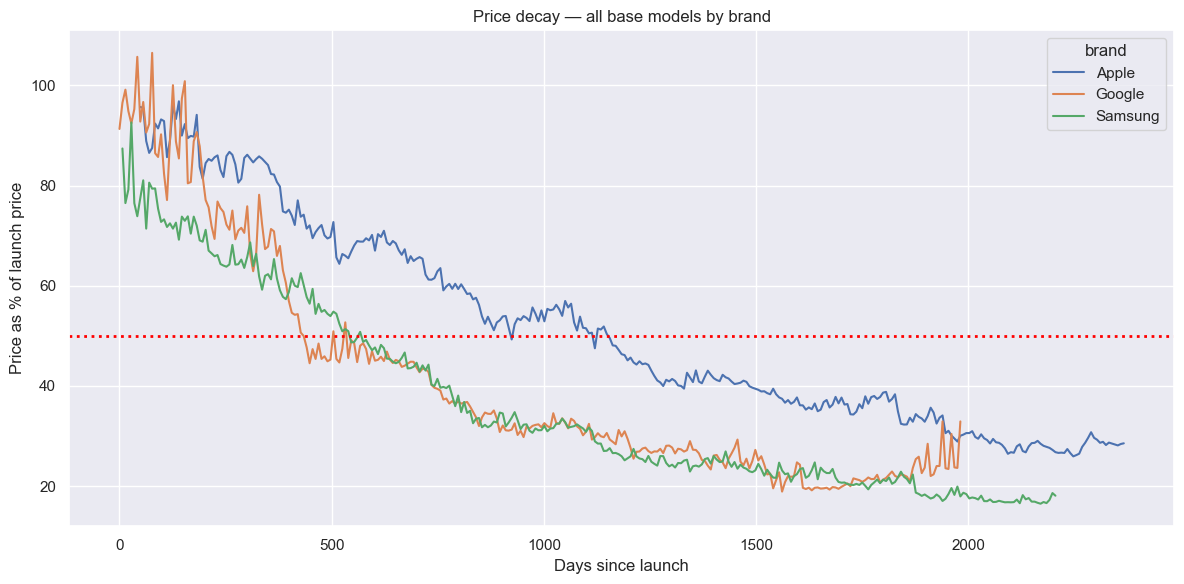

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1d = sns.lineplot(data=all_brands_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='brand', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay — all base models by brand')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()


iPhone'y jako ostatnie przekraczają granicę 50%, dopiero około 900 dni po premierze.
Samsung osiąga ten poziom mniej więcej po 500 dniach, Google po około 420 dniach. Apple ma też najwyższe ceny minimalne, stabilizując się na poziomie 26-28% ceny premierowej po około 2000 dniach. Samsung spada do 16-17%, Google do około 20%.

**Modele bazowe iPhone'ów według generacji**

iPhone'y na Amazon są sprzedawane wyłącznie jako Renewed lub Renewed Premium. Linie ciągłe to standardowa klasa Renewed, linie przerywane to Renewed Premium.

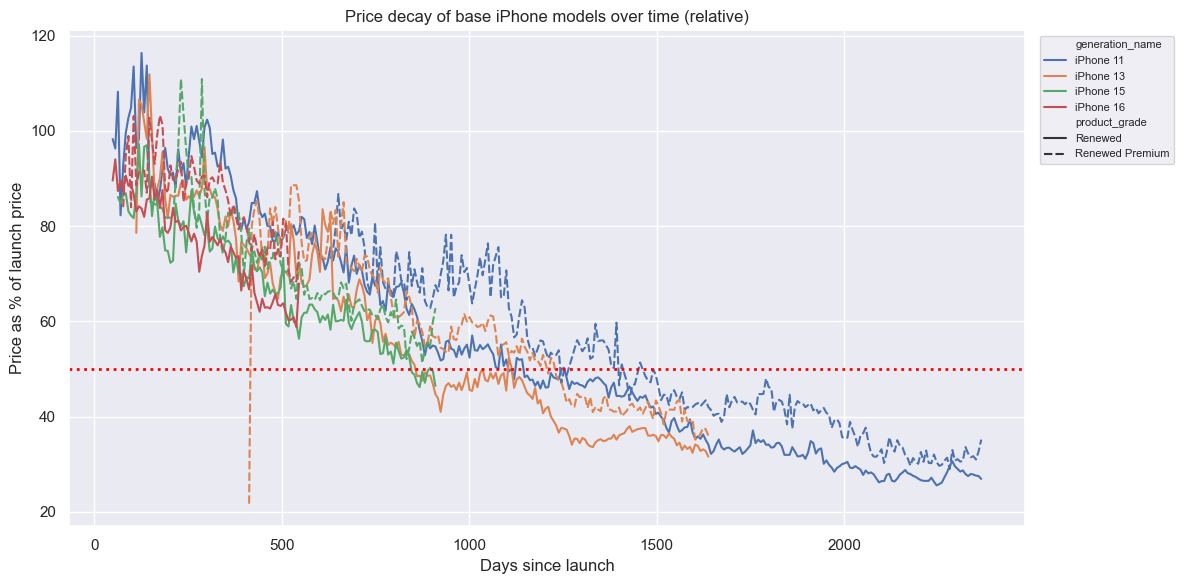

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1 = sns.lineplot(data=base_apple_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', style='product_grade', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base iPhone models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


Wersja Renewed Premium konsekwentnie utrzymuje się powyżej krzywej standardowej wersji Renewed dla tej samej generacji.

Różnica pojawia się wcześnie i w miarę stabilnie utrzymuje się przez cały czas, co sugeruje, że kupujący płacą premię za lepszy stan produktu niezależnie od wieku telefonu. Różnica waha się w zależności od generacji, ale średnio wynosi około 10,2 punktu procentowego.

**Modele bazowe Samsunga według generacji**

Uwaga: rozróżnienie według product_grade nie miało tu sensu, bo poza jednym przypadkiem mieliśmy praktycznie same wersje Renewed.

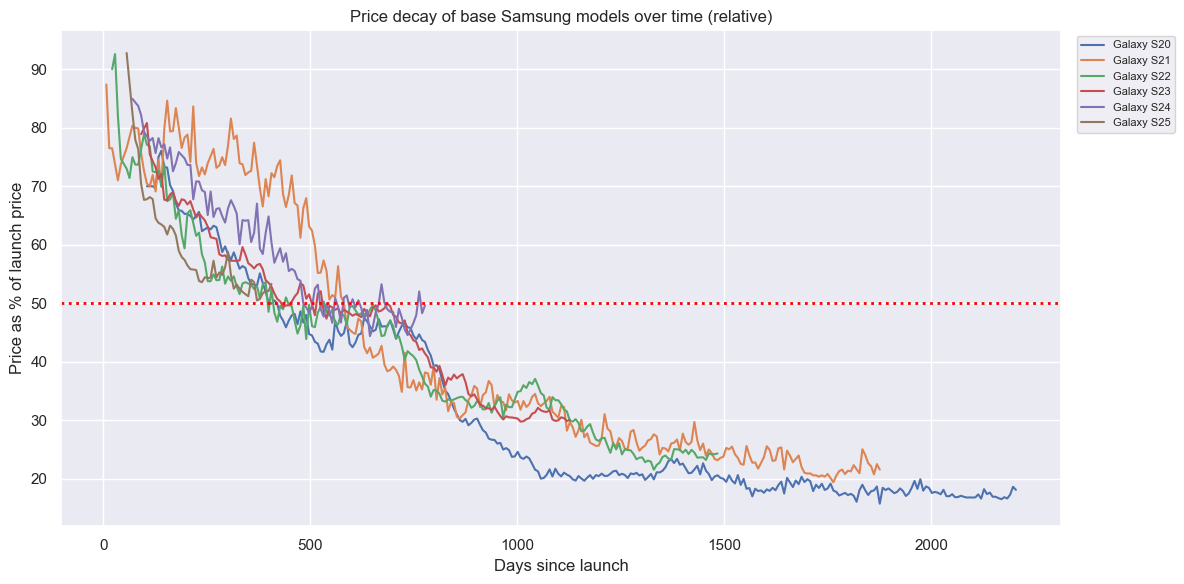

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1b = sns.lineplot(data=base_samsung_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base Samsung models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


**Modele bazowe Google Pixel według generacji**

Uwaga: podobnie jak w przypadku Samsunga, rozróżnienie według product_grade nie miało sensu.

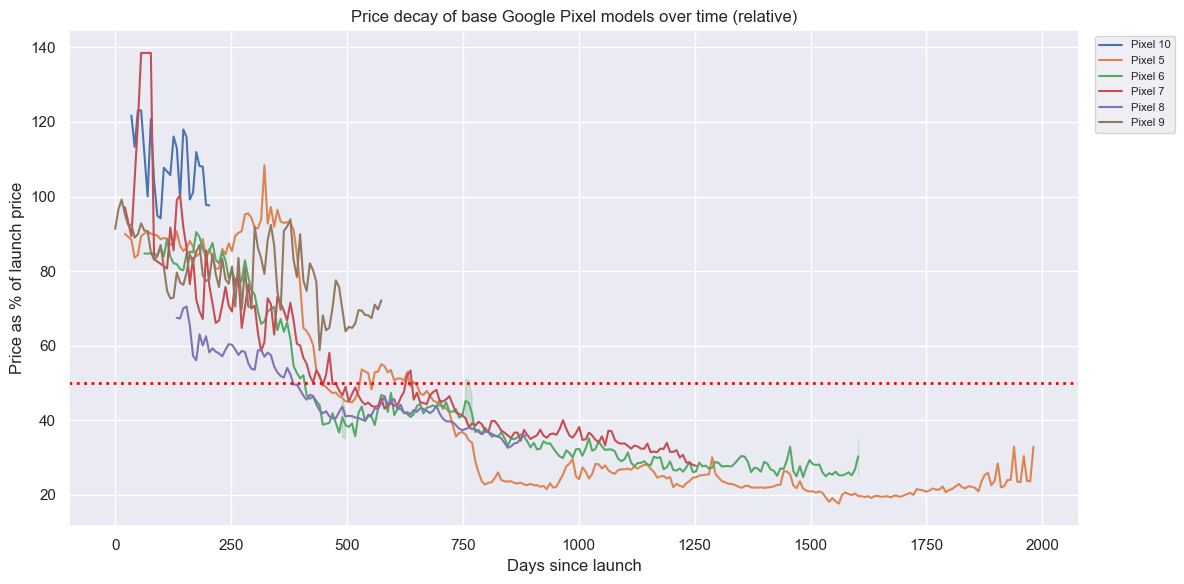

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1c = sns.lineplot(data=base_google_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base Google Pixel models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


**Spadek cen na przykładzie submodeli iPhone'a 13**

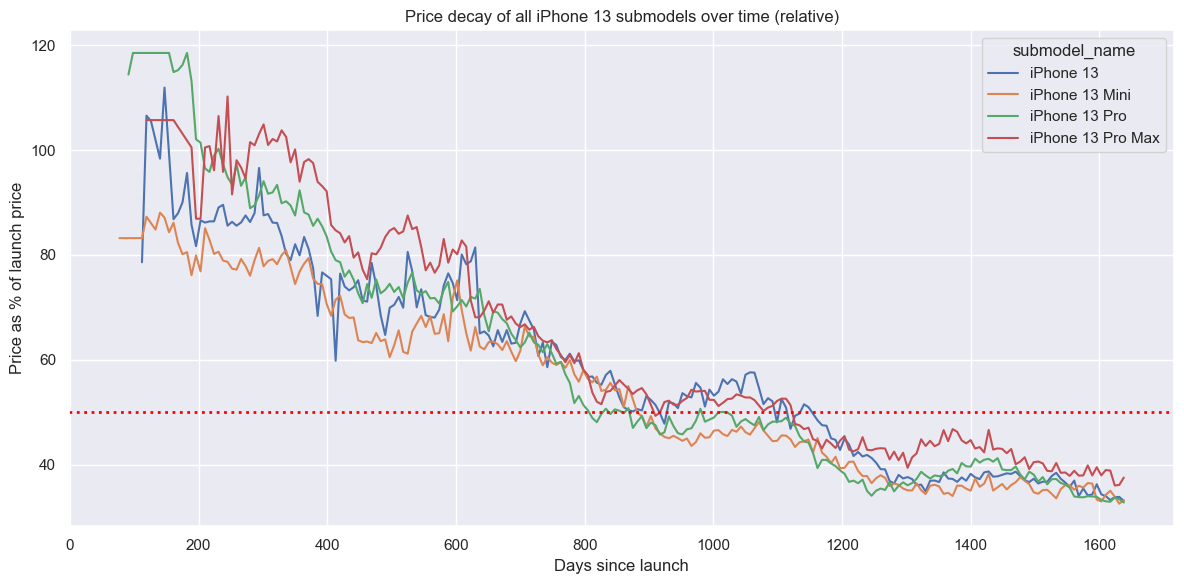

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_2 = sns.lineplot(data=iphone13_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='submodel_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of all iPhone 13 submodels over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()


Pro Max konsekwentnie utrzymuje najlepszą retencję wartości na niemal każdym etapie cyklu życia. Co ciekawe, nawet po 1600 dniach zachowuje około 40% ceny premierowej.

Na przeciwnym biegunie Mini zdaje się tracić wartość najszybciej, co prawdopodobnie odzwierciedla niższy popyt konsumencki i mniejszą popularność tego submodelu na rynku wtórnym.

---
# Porównanie marek rok po premierze

Zamiast analizować pełną krzywą deprecjacji, tutaj robimy migawkę w okolicach 365 dni od premiery i ustawiamy wszystkie generacje obok siebie. Dzięki temu zyskujemy kolejną perspektywę na to jak dana marka utrzymuje cenę.

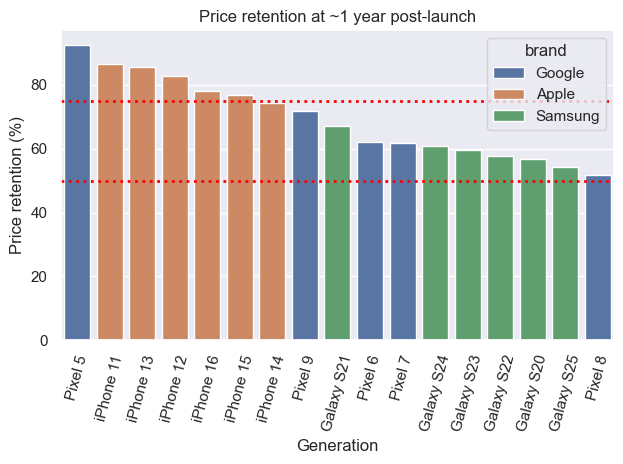

In [11]:
order = retention_1yr_df['generation_name'].tolist()

pd_chart_7 = sns.barplot(
    data=retention_1yr_df,
    x='generation_name',
    y='price_retention',
    hue='brand',
    order=order)

plt.axhline(75, color='red', linestyle='dotted', linewidth=2)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Price retention at ~1 year post-launch')
plt.xlabel('Generation')
plt.ylabel('Price retention (%)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


iPhone'y dominują w górnej części wykresu. Pixel 5 wyróżnia się wśród telefonów Google. Prawdopodobnie wynika to z niskiej ceny premierowej ($699) i wczesnego wycofania go przez Google, co ograniczyło podaż i podtrzymało wartość. Inne Pixele, które trafiły na rynek w wyższej cenie i pozostały w sprzedaży dłużej zachowały się już zupełnie inaczej.

---
# Rozkład cen przez cały cykl

Boxplot przedstawia pełny rozkład tygodniowych cen na podstawie całej historii dla każdej marki: medianę, kwartyle i outliery. Widzimy tu też jak duże są wahania ceny telefonów każdej marki.

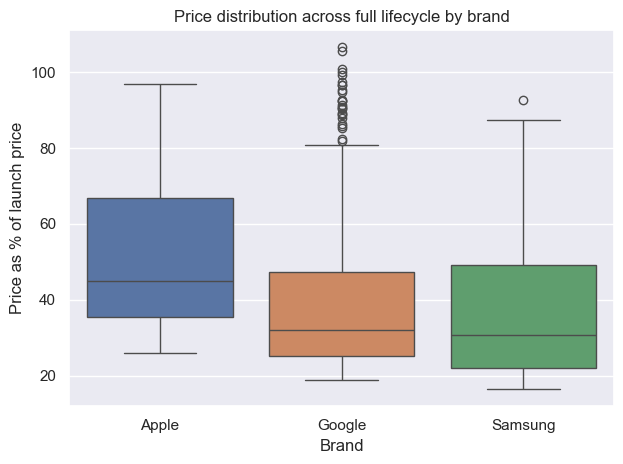

In [12]:
pd_chart_8 = sns.boxplot(
    data=all_brands_decay_df,
    x='brand',
    y='price_pct_of_launch',
    hue='brand')
plt.title('Price distribution across full lifecycle by brand')
plt.xlabel('Brand')
plt.ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()


Apple wyraźnie wiedzie prym pod względem mediany, IQR marki jest przesunięty wyżej niż u konkurencji. Google i Samsung mają bardzo podobne rozkłady z drobnymi różnicami, bo Google ma też najwyższą liczbę outlierów.

---
# Analiza rankingu sprzedaży

Wartość monthly_sold w API Keepy to pozycja w rankingu sprzedaży, a nie liczba sprzedanych egzemplarzy: niższy ranking (monthly_sold) oznacza, że produkt sprzedaje się lepiej. Keepa śledzi te dane dopiero od końca 2023 roku, więc mamy tylko około 2 lat danych. Zastanawiałem się, czy w ogóle to uwzględniać, ale uznałem, że skoro nie mamy wolumenów sprzedażowych, to chociaż to musi sie pojawić i nawet taka ilość danych powinna wystarczyć, żeby zaobserwować pewne wzorce.

**Ranking sprzedaży - bazowe iPhone'y**

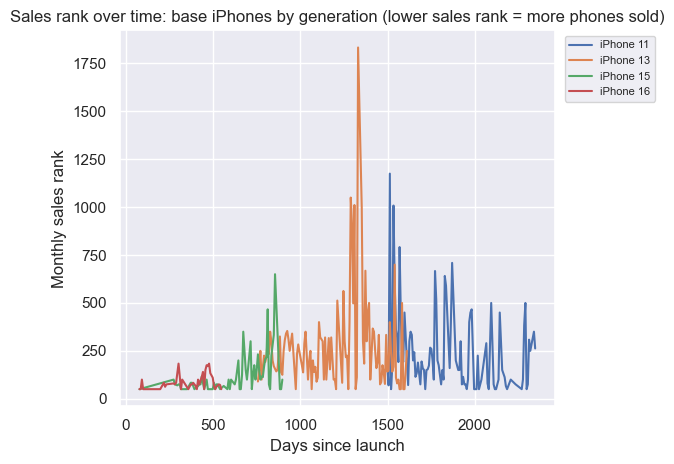

In [13]:
ms_chart_3 = sns.lineplot(
    data=apple_base_rank_df,
    x='days_rounded',
    y='monthly_sold',
    hue='generation_name')

plt.title('Sales rank over time: base iPhones by generation (lower sales rank = more phones sold)')
plt.xlabel('Days since launch')
plt.ylabel('Monthly sales rank')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


Analiza sprzedaży iPhone'ów pokazuje utrzymujący się popyt konsumencki w zasadzie w każdej analizowanej generacji. Starsze modele nadal radzą sobie dobrze, regularnie plasując się w przedziale top 50-500. Wolumen sprzedaży wykazuje wyraźną sezonowość i wahania.

**Ranking sprzedaży w obrębie generacji - submodele iPhone'ów 13 i 16**

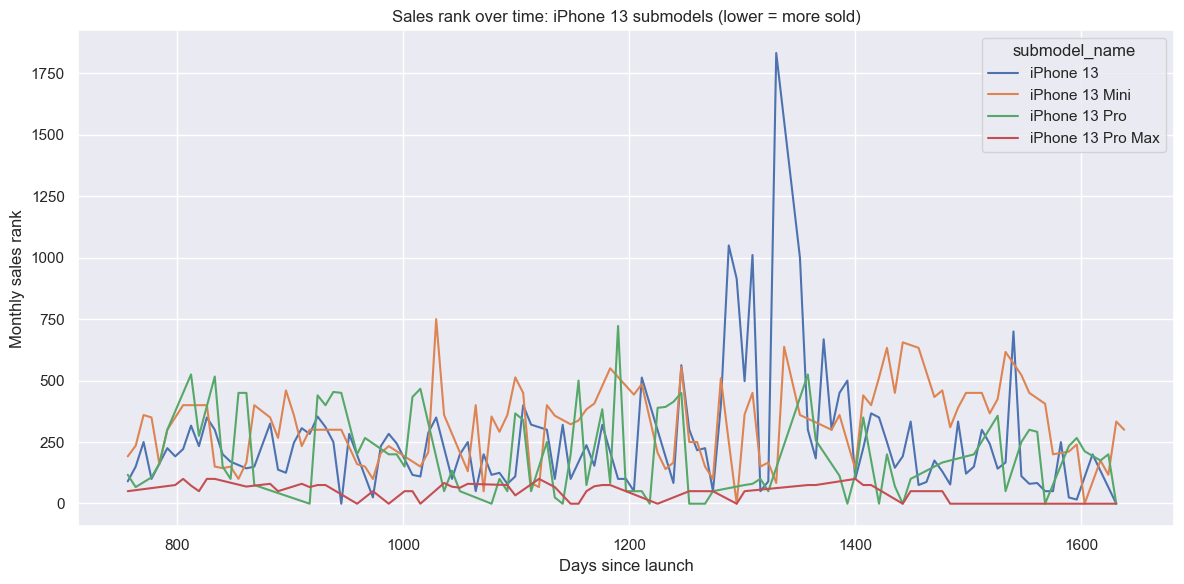

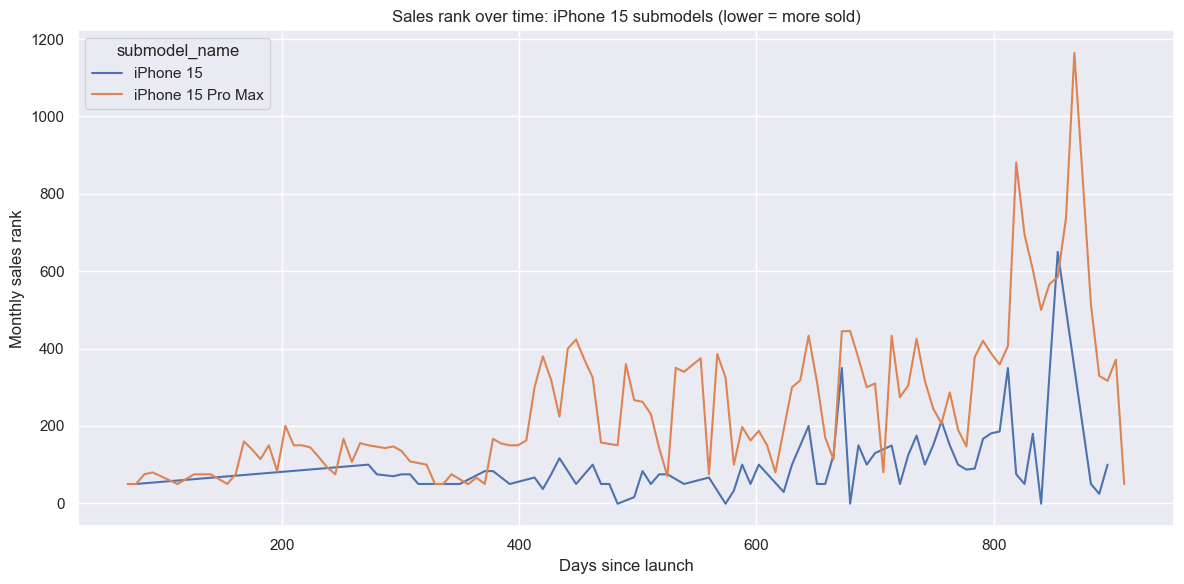

In [14]:
plt.subplots(figsize=(12, 6))

ms_chart_4 = sns.lineplot(
    data=iphone13_rank_df,
    x='days_rounded',
    y='monthly_sold',
    hue='submodel_name')

plt.title('Sales rank over time: iPhone 13 submodels (lower = more sold)')
plt.xlabel('Days since launch')
plt.ylabel('Monthly sales rank')
plt.tight_layout()
plt.show()

plt.subplots(figsize=(12, 6))

ms_chart_5 = sns.lineplot(
    data=iphone15_rank_df,
    x='days_rounded',
    y='monthly_sold',
    hue='submodel_name')

plt.title('Sales rank over time: iPhone 15 submodels (lower = more sold)')
plt.xlabel('Days since launch')
plt.ylabel('Monthly sales rank')
plt.tight_layout()
plt.show()


Pro Max okazuje się najpopularniejszym submodelem w linii iPhone'a 13. Może to być nieoczywiste, bo logika podpowiada, że tańszy model powinien sprzedawać się lepiej, ale na tym etapie Pro Max jest mocno przeceniony względem ceny premierowej i oferuje najlepsze możliwości w swojej generacji. Klienci szukający flagowca w budżetowej cenie często sięgają po topowy wariant, gdy tylko cena na to pozwala.

Dane iPhone'a 15 pokazują zachowanie krótko po premierze i widzimy tu zdecydowanie inną dynamikę: model bazowy generuje największy wolumen, prawdopodobnie przez to, że cena Pro Maxa stanowi wysoką barierę wejścia. Można przypuszczać, że z czasem zajdzie tu podobna zależność, co w przypadku 13stki.

**Ranking sprzedaży według rzeczywistych dat - bazowe iPhone'y**

Analiza prawdziwych dat zamiast względnych dni od premiery pozwala wychwycić wzorce sezonowe.
Szare przerywane linie oznaczają okno premiery iPhone'a (wrzesień), pomarańczowe - Black Friday, czerwone - Boże Narodzenie, fioletowe - Prime Day.

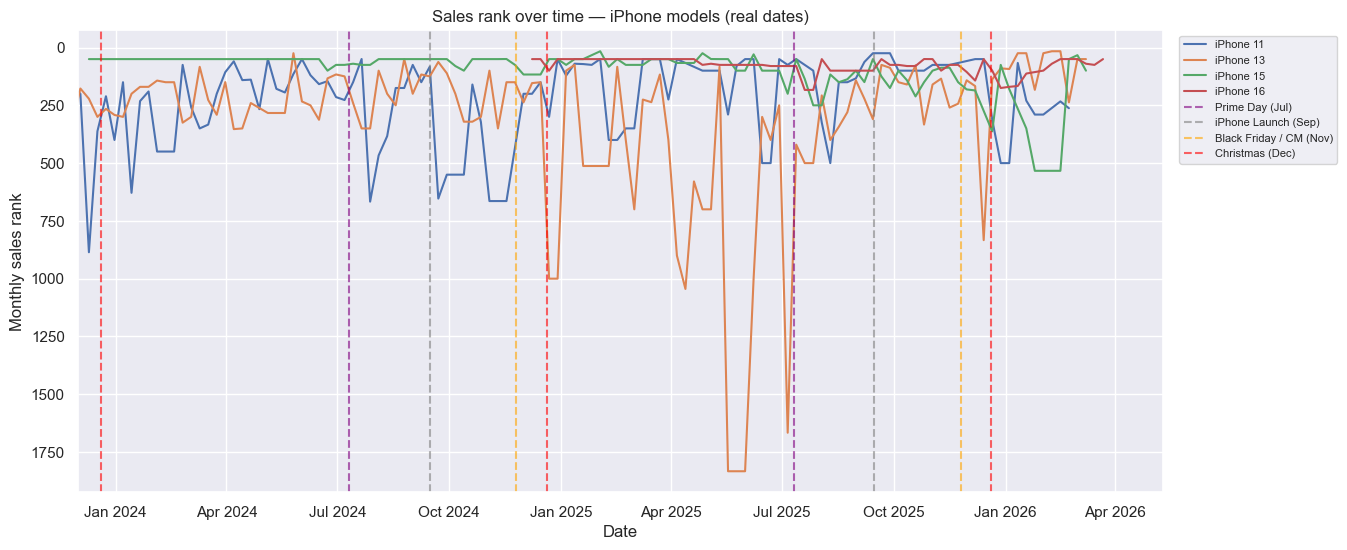

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_5 = sns.lineplot(data=apple_base_rank_dates_df, x='datetime', y='monthly_sold',
    hue='generation_name', ax=ax)
ax.invert_yaxis()

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales rank over time — iPhone models (real dates)')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales rank')
ax.set_xlim(left=pd.Timestamp('2023-12-01'))
plt.show()


1. Mimo ograniczonych danych, najbardziej uderzającym wnioskiem jest niezwykła siła popytu na iPhone'y. Sprzedaż utrzymuje relatywnie wysoki poziom w zasadzie przez cały rok.

2. iPhone 15 utrzymywał się bardzo wysoko w rankingu aż do premiery iPhone'a 17, która spowodowała niewielki spadek. Aktualnie iPhone 16 zdaje się być liderem sprzedaży, nieznacznie wyprzedzając iPhone'a 15.

3. Starsze generacje (11/13) wykazują znacznie wyższą zmienność, ze wyraźnymi wzrostami pod koniec roku. Pomimo tych wahań obie generacje trzymają się mocno w przedziale top 500-750, a iPhone 11 nieznacznie wyprzedza iPhone'a 13 jako bardziej budżetowy wariant.

**Submodele iPhone'a 13 według rzeczywistych dat**

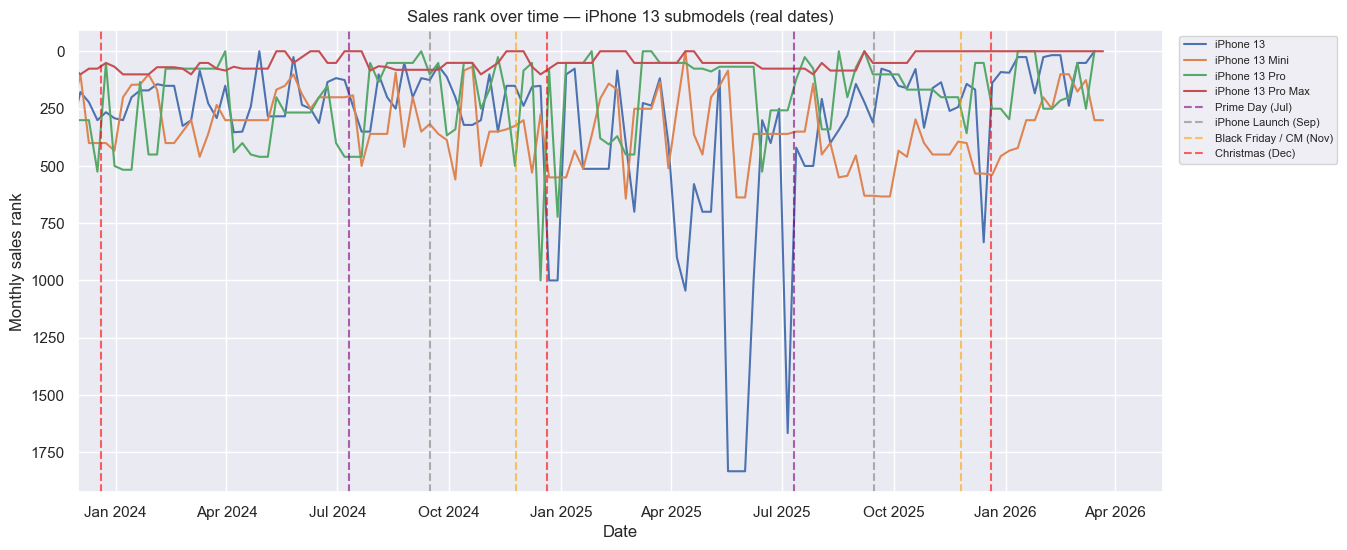

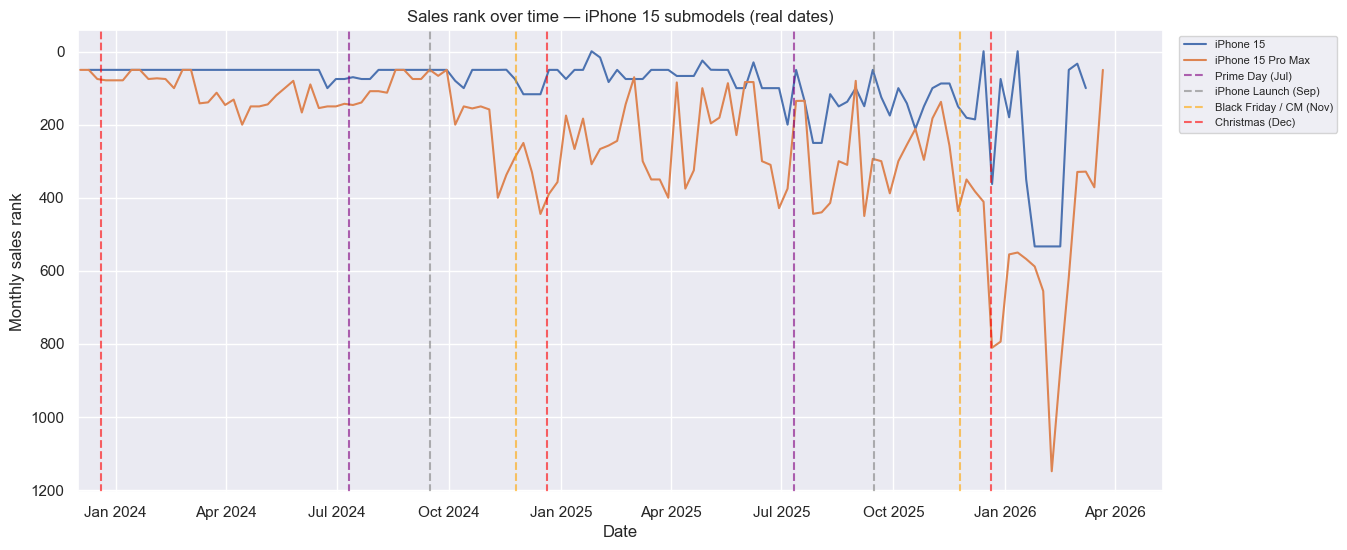

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_6 = sns.lineplot(data=iphone13_rank_dates_df, x='datetime', y='monthly_sold',
    hue='submodel_name', ax=ax)

ax.invert_yaxis()

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales rank over time — iPhone 13 submodels (real dates)')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales rank')
ax.set_xlim(left = pd.Timestamp('2023-12-01'))
plt.show()



fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_7 = sns.lineplot(data=iphone15_rank_dates_df, x='datetime', y='monthly_sold',
    hue='submodel_name', ax=ax)
ax.invert_yaxis()

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales rank over time — iPhone 15 submodels (real dates)')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales rank')
ax.set_xlim(left = pd.Timestamp('2023-12-01'))
plt.show()

Patrząc na iPhone'a 15, widać wyraźny spadek sprzedaży wersji Pro Max bezpośrednio po premierze iPhone'a 16, a jeszcze ostrzejszy po premierze iPhone'a 17. Co ciekawe, model ten ostatnio zaczął odzyskiwać pozycję rynkową. W obrębie generacji iPhone'a 15, Pro Max wykazuje znacznie wyższą zmienność w porównaniu do stabilnego modelu bazowego.

To zachowanie wyraźnie kontrastuje z iPhone'em 13, gdzie role są odwrócone: tam to Pro Max pełni funkcję stabilnej kotwicy z konsekwentnie wysokim popytem przez cały rok, podczas gdy model bazowy jest bardziej zmienny. Różnice są wyraźne, ale i tak można powiedzieć, że wszystkie badane submodele utrzymują wysoki poziom bazowy popularności.

---
# Kluczowe wnioski

- **Apple najlepiej utrzymuje wartość.** Rok po premierze iPhone'y radzą sobie wyraźnie lepiej niż konkurencja z Samsung czy Google. Spadek ceny o 50% pojawia się po około 900 dniach dla Apple, po około 500 dniach w przypadku Samsunga i 420 dla Google.

- **Wersja Renewed Premium utrzymuje wartość lepiej niż standardowy Renewed.** W przypadku iPhone'ów różnica w cenie wynosi średnio 10,2 punktu procentowego i pozostaje w miarę stabilna przez cały cykl historii ceny.

- **Pixel 5 jest anomalią.** Wyprzedza wszystkie inne modele Google rok po premierze. Niska cena startowa i wcześniejsze wycofanie ze sprzedaży ograniczyły podaż na rynku wtórnym i utrzymały wartość dłużej niż można by się spodziewać.

- **Starsze flagowce lepiej przyciągają kupujących.** iPhone 13 Pro Max regularnie notuje wyższy ranking sprzedaży niż inne submodele tej samej generacji. Dane pokazują też, że modele bazowe sprzedają się lepiej na początku, a Pro Max zyskuje z czasem.

- **Sprzedaż zdaje się rosnąć pod koniec roku.** Wartość monthly_sold jest dostępna dopiero od końca 2023 roku, co utrudnia wyciąganie wniosków o wpływie Black Friday, Prime Day czy Bożego Narodzenia na cenę i popyt. Widać pewne sygnały sezonowości i ślady spadku popytu po premierach. Smartfony od Apple ewidentnie utrzymują popyt przez cały rok, ale przy tym szczególnie dobrze sprzedają się w ostatnim kwartale.